# 03 — Visualization & Evaluation

This notebook only reads results — it doesn't train anything. It loads what notebooks 1 and 2
saved and produces the plots needed to actually judge whether the regime-specific approach is
working: loss curves, accuracy curves, confusion matrices, a direct comparison against the
single whole-dataset baseline model, and a directional-bias check (actual vs predicted "up"
days per model).

**Input:** `reports/baseline_results.pkl` (notebook 1) and `reports/regime_results.pkl`
(notebook 2). Run those two notebooks first if these files don't exist yet.
**Output:** every figure below is saved into `reports/`, using a dark theme throughout.


In [2]:
from google.colab import files
files.upload()          # pick Week4_SOC.zip
!unzip -oq Week4_SOC.zip
%cd /content/Week4

Saving Week4_SOC.zip to Week4_SOC.zip
/content/Week4


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================================================
# Constants
# ============================================================================
REPORTS_DIR = "reports"   # every figure produced in this notebook is saved here

PALETTE = {
    "base":            "#58a6ff",
    "uptrend":         "#2ecc71",
    "downtrend":       "#e74c3c",
    "high":            "#f39c12",
    "sideways":        "#95a5a6",
}

# Dark background theme for every figure in this notebook.
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#0d1117",
    "savefig.facecolor": "#0d1117",
    "axes.grid": True,
    "grid.alpha": 0.25,
})

with open(f"{REPORTS_DIR}/baseline_results.pkl", "rb") as f:
    baseline = pickle.load(f)
with open(f"{REPORTS_DIR}/regime_results.pkl", "rb") as f:
    regime_results = pickle.load(f)

# Merge into one dict keyed by model name, baseline included as "base_lstm"
all_histories = {"base_lstm": baseline["history"], **regime_results["histories"]}
all_metrics   = {"base_lstm": baseline["metrics"],  **regime_results["metrics"]}
cv_results    = regime_results.get("cv_results", {})

MODEL_NAMES = list(all_metrics.keys())
print("Loaded models:", MODEL_NAMES)


def color_for(name):
    return PALETTE.get(name.split("_")[0], PALETTE["base"])


Loaded models: ['base_lstm', 'uptrend_lstm', 'downtrend_lstm', 'sideways_bilstm']


## 1. Training & validation loss curves

If validation loss climbs back up after an initial drop, the model is overfitting past that
point — the early-stopping checkpoint should be from before that happens, which is exactly what
the training loop in notebook 2 restores automatically. These curves are how you'd notice it
wasn't working.


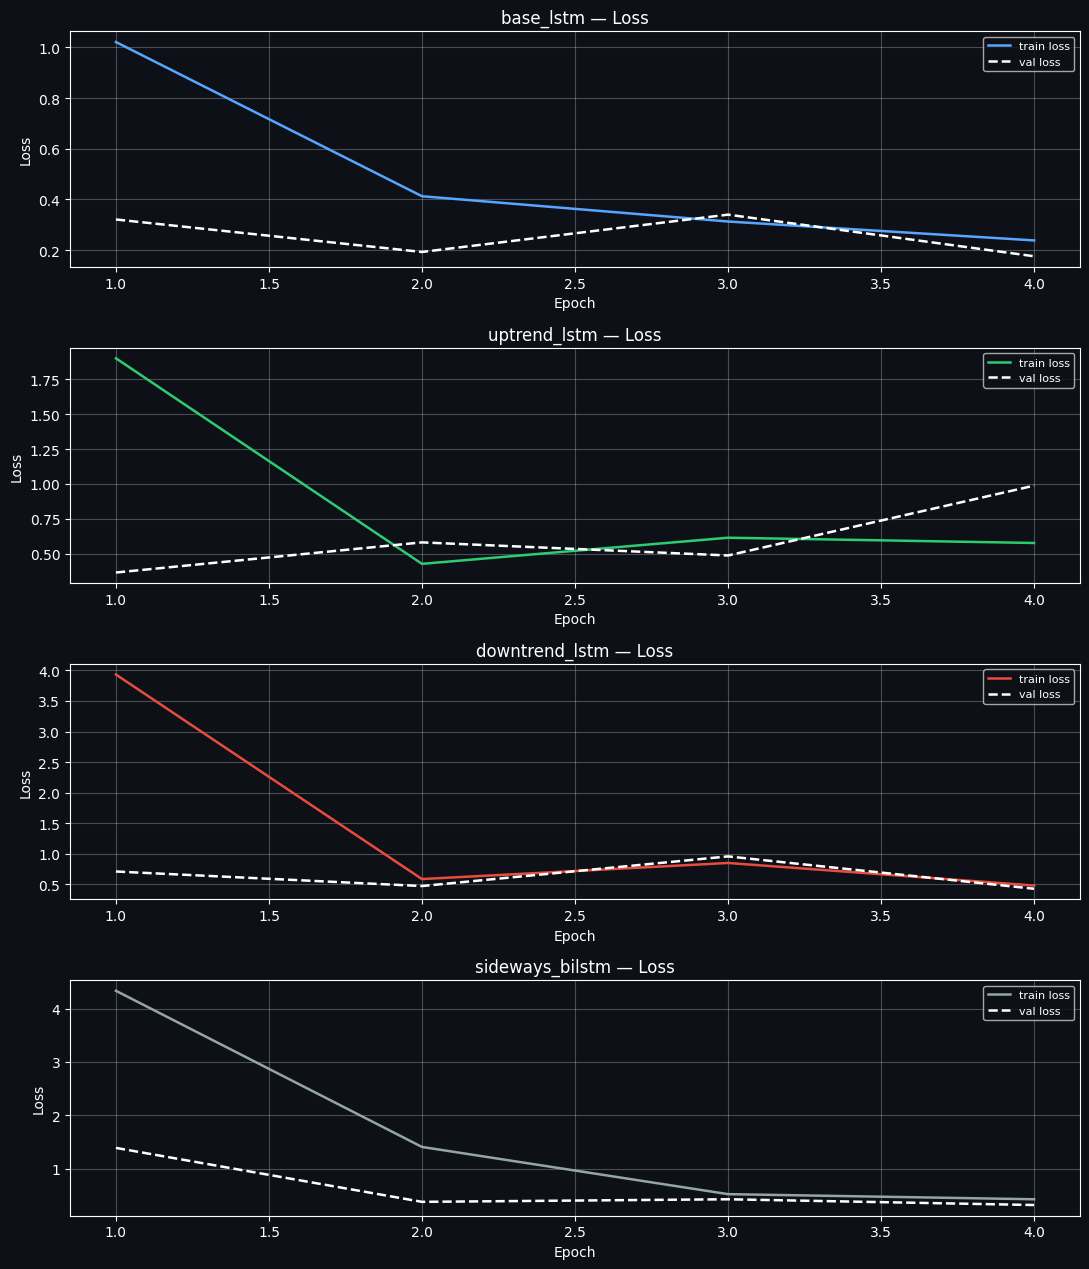

In [4]:
n = len(MODEL_NAMES)
fig, axes = plt.subplots(n, 1, figsize=(11, 3.2 * n))
if n == 1:
    axes = [axes]

for ax, name in zip(axes, MODEL_NAMES):
    h = all_histories[name]
    epochs = range(1, len(h["train_loss"]) + 1)
    color = color_for(name)
    ax.plot(epochs, h["train_loss"], color=color, lw=1.8, label="train loss")
    ax.plot(epochs, h["val_loss"], color="white", lw=1.8, linestyle="--", label="val loss")
    ax.set_title(f"{name} — Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/fig_loss_curves.png", dpi=140)
plt.show()


## 2. Validation direction accuracy curves

For the smallest regime (`high_volatility`), the shaded band shows the 5-fold cross-validation
mean ± 1 standard deviation instead of a single run — with under 200 training sequences, a
single validation split is too noisy to read on its own.


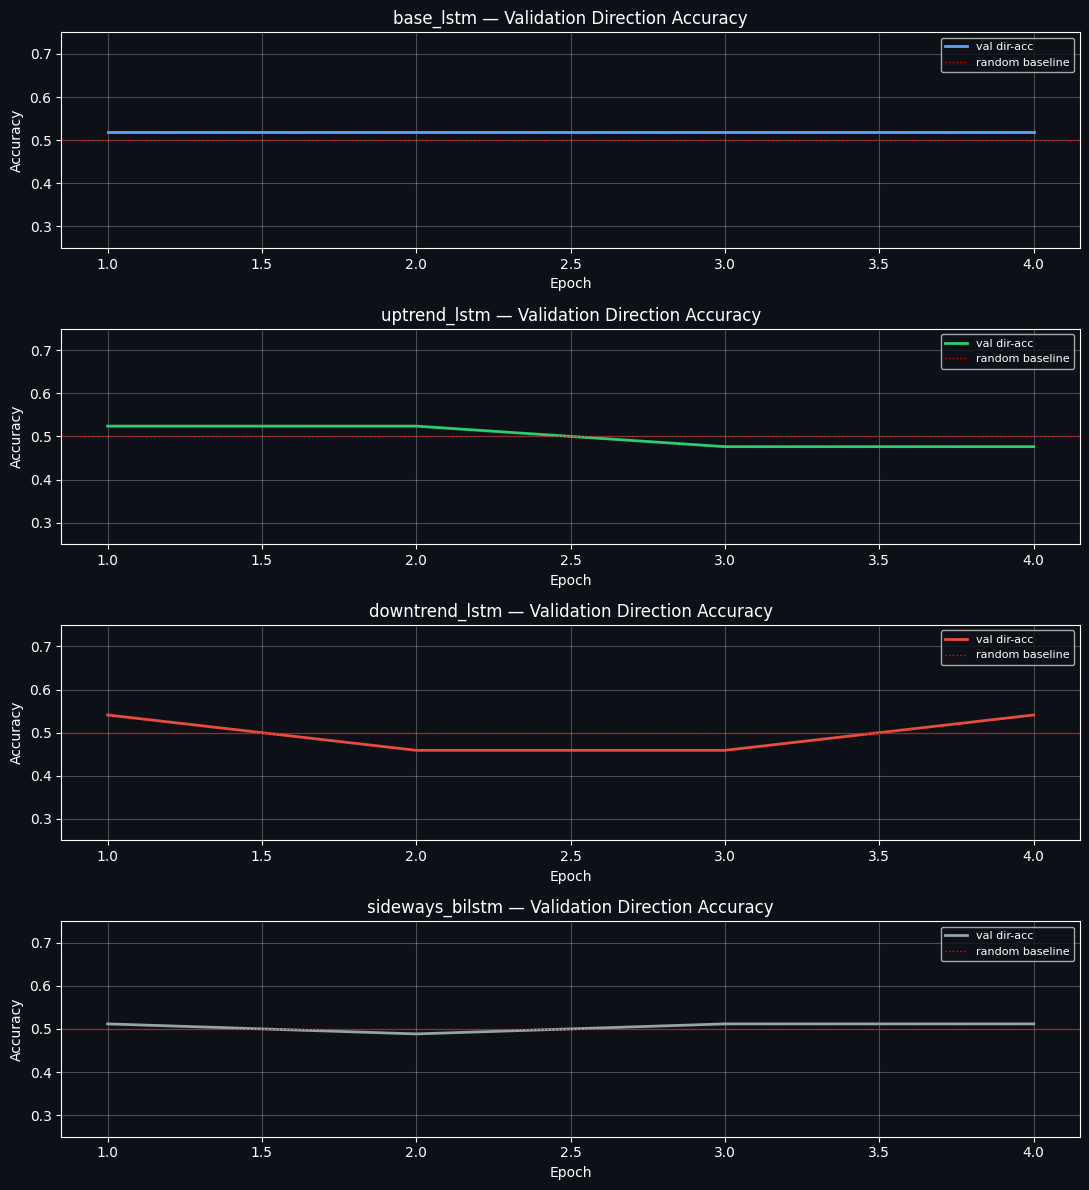

In [ ]:
fig, axes = plt.subplots(n, 1, figsize=(11, 3.0 * n))
if n == 1:
    axes = [axes]

for ax, name in zip(axes, MODEL_NAMES):
    h = all_histories[name]
    epochs = range(1, len(h["val_dir_acc"]) + 1)
    color = color_for(name)
    ax.plot(epochs, h["val_dir_acc"], color=color, lw=2, label="val dir-acc")
    ax.axhline(0.5, color="red", lw=1, linestyle=":", label="random baseline")
    if name in cv_results:
        cv = cv_results[name]
        ax.axhline(cv["cv_dir_acc"], color="orange", lw=1.2, linestyle="--",
                   label=f"5-fold CV mean = {cv['cv_dir_acc']:.3f} +/- {cv['cv_dir_std']:.3f}")
    ax.set_ylim(0.25, 0.75)
    ax.set_title(f"{name} — Validation Direction Accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/fig_accuracy_curves.png", dpi=140)
plt.show()


## 3. Confusion matrices

Accuracy alone can hide a model that's mostly calling one direction — a model that predicts *every* day as "Up" still achieves ≈50% accuracy on a balanced dataset but is useless.

**Your task — complete the confusion matrix plotting loop (cell below):**

For each `(ax, name)` pair:
1. Retrieve `y_test` and `preds` from `all_metrics[name]`.
2. Build a 2×2 confusion matrix using `confusion_matrix(y_test > 0, preds > 0)`.
3. Use `ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(ax=ax, colorbar=False, cmap="Blues")` to render it.
4. Count predicted Up and Down days, then set a title showing the model name, its `direction_accuracy`, and the predicted class counts.
5. Turn off unused axes (when `len(MODEL_NAMES)` doesn't fill the grid evenly).

The grid dimensions (`ncols`, `nrows`, figure size) and the `axes` flattening are already set up for you.


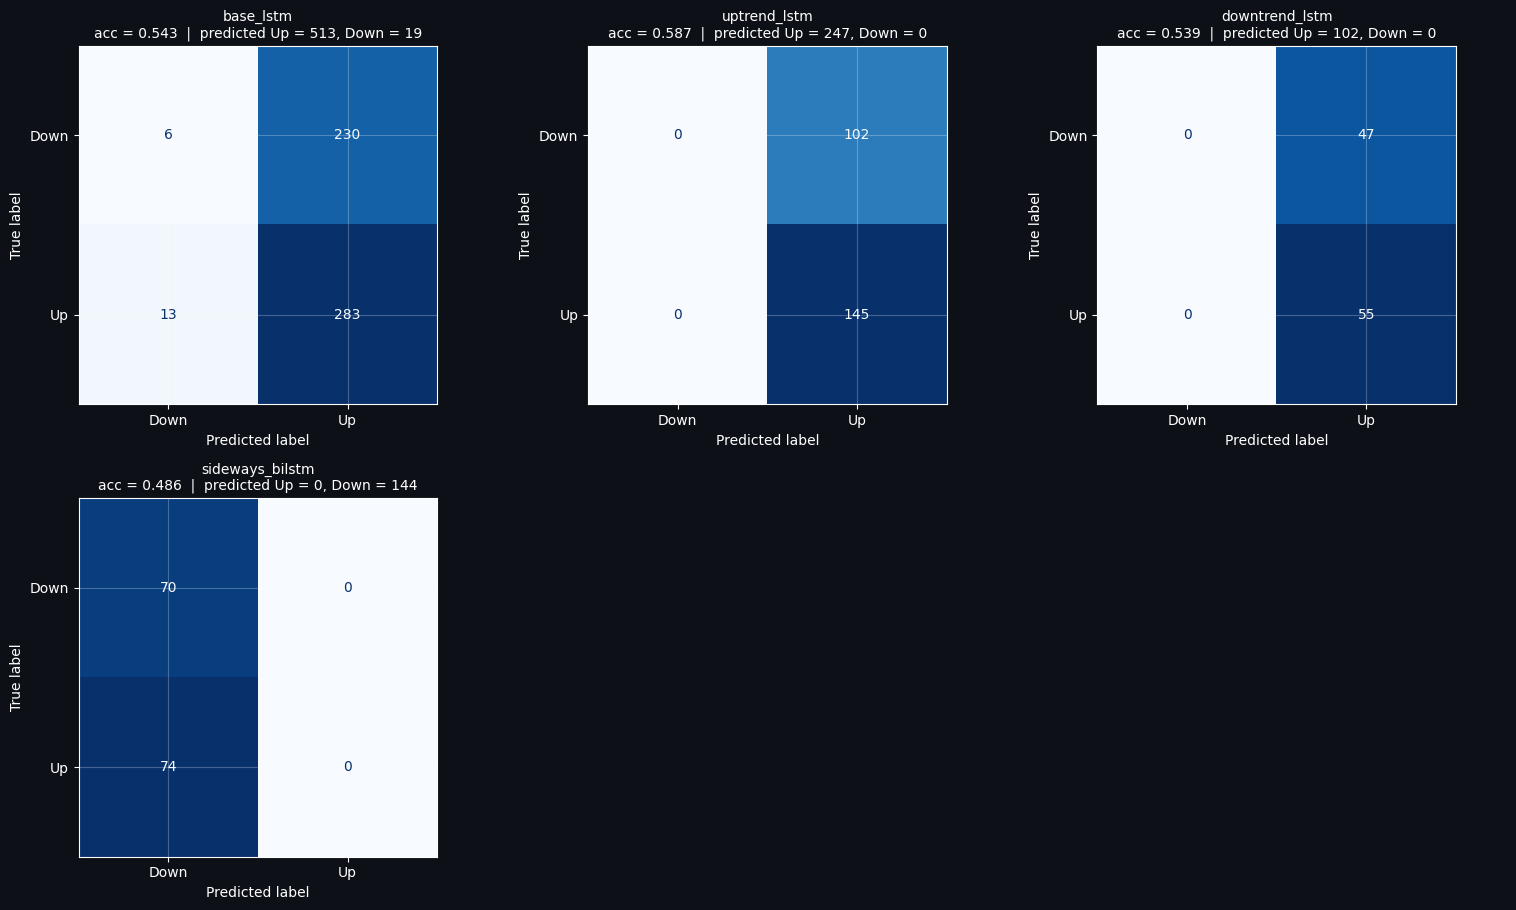

In [ ]:
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, name in zip(axes, MODEL_NAMES):
    m = all_metrics[name]
    y_test, preds = m["y_test"], m["preds"]

    cm = confusion_matrix(y_test > 0, preds > 0)
    ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(
        ax=ax, colorbar=False, cmap="Blues")

    n_pred_up   = int((preds > 0).sum())
    n_pred_down = int((preds <= 0).sum())
    ax.set_title(f"{name}\nacc = {m['direction_accuracy']:.3f}  |  "
                 f"predicted Up = {n_pred_up}, Down = {n_pred_down}", fontsize=10)

# Blank out any leftover axes so a partially-filled grid doesn't render empty boxes.
for ax in axes[len(MODEL_NAMES):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/fig_confusion_matrices.png", dpi=140)
plt.show()


## 4. Baseline vs regime-specific: does the extra complexity earn its keep?

The whole-dataset baseline model is the bar every regime-specific model needs to clear. If a
regime model doesn't beat the baseline on its own slice of data, that regime isn't benefiting
from specialisation — it would do just as well (or better) falling back to the baseline, which
is exactly the fallback behaviour this kind of system should have for any regime that fails this
check.


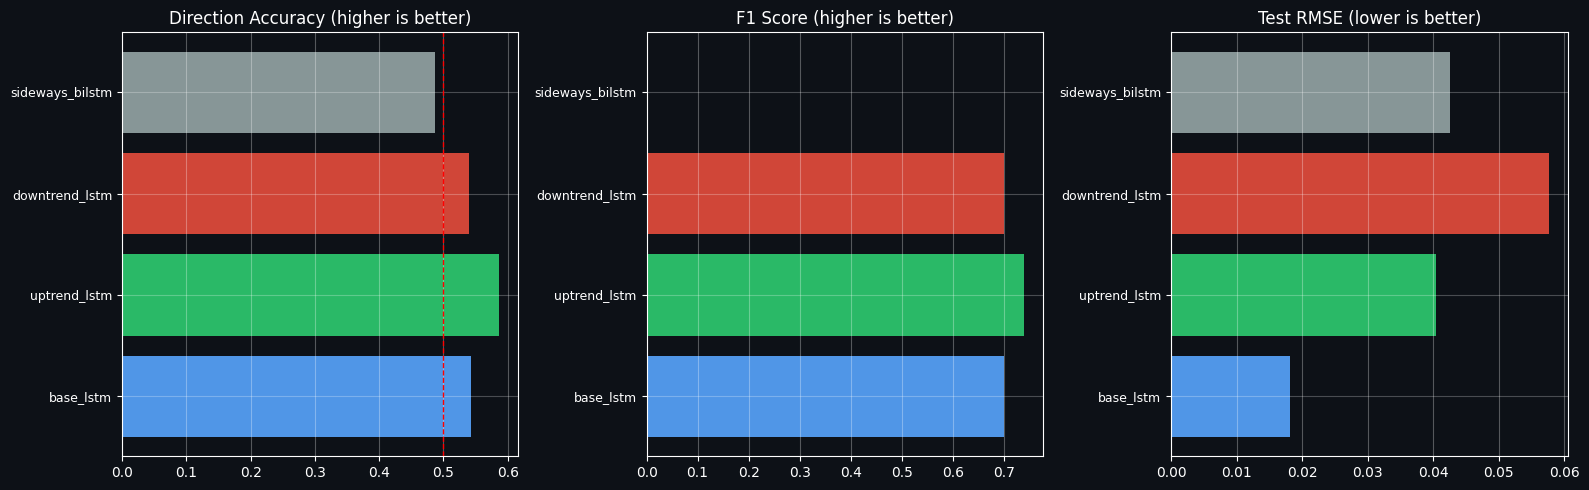

In [ ]:
metric_keys = ["direction_accuracy", "f1_score", "test_rmse"]
labels      = ["Direction Accuracy", "F1 Score", "Test RMSE"]
better      = ["higher", "higher", "lower"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
y = np.arange(len(MODEL_NAMES))

for ax, key, label, direction in zip(axes, metric_keys, labels, better):
    vals = [all_metrics[n][key] for n in MODEL_NAMES]
    colors = [color_for(n) for n in MODEL_NAMES]
    ax.barh(y, vals, color=colors, alpha=0.9)
    if key == "direction_accuracy":
        ax.axvline(0.5, color="red", linestyle="--", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(MODEL_NAMES, fontsize=9)
    ax.set_title(f"{label} ({direction} is better)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/fig_baseline_vs_regime.png", dpi=140)
plt.show()


## 5. Predicted vs actual returns, and rolling accuracy

The scatter plot checks whether model errors are symmetric around the diagonal. The rolling accuracy panel reveals whether skill is stable over time or just concentrated in a lucky window.

**Your task — complete the rolling accuracy panel (right column) inside the loop below:**

For each model row (`axes[row, 1]`):
1. Get `y_test` and `preds` from `all_metrics[name]`.
2. Build a boolean `correct` array: `True` where the predicted direction matches actual.
3. Choose a rolling `window = max(min(30, len(correct) // 4), 2)`.
4. Compute a rolling mean of `correct` using `pd.Series(correct).rolling(window).mean()`.
5. Plot `roll_acc` on the axis, add a horizontal 0.5 baseline (dashed red), set y-limits to `[0.1, 0.9]`, and add axis labels and a title.

The scatter plot (left column) is already implemented — only the right column needs work.


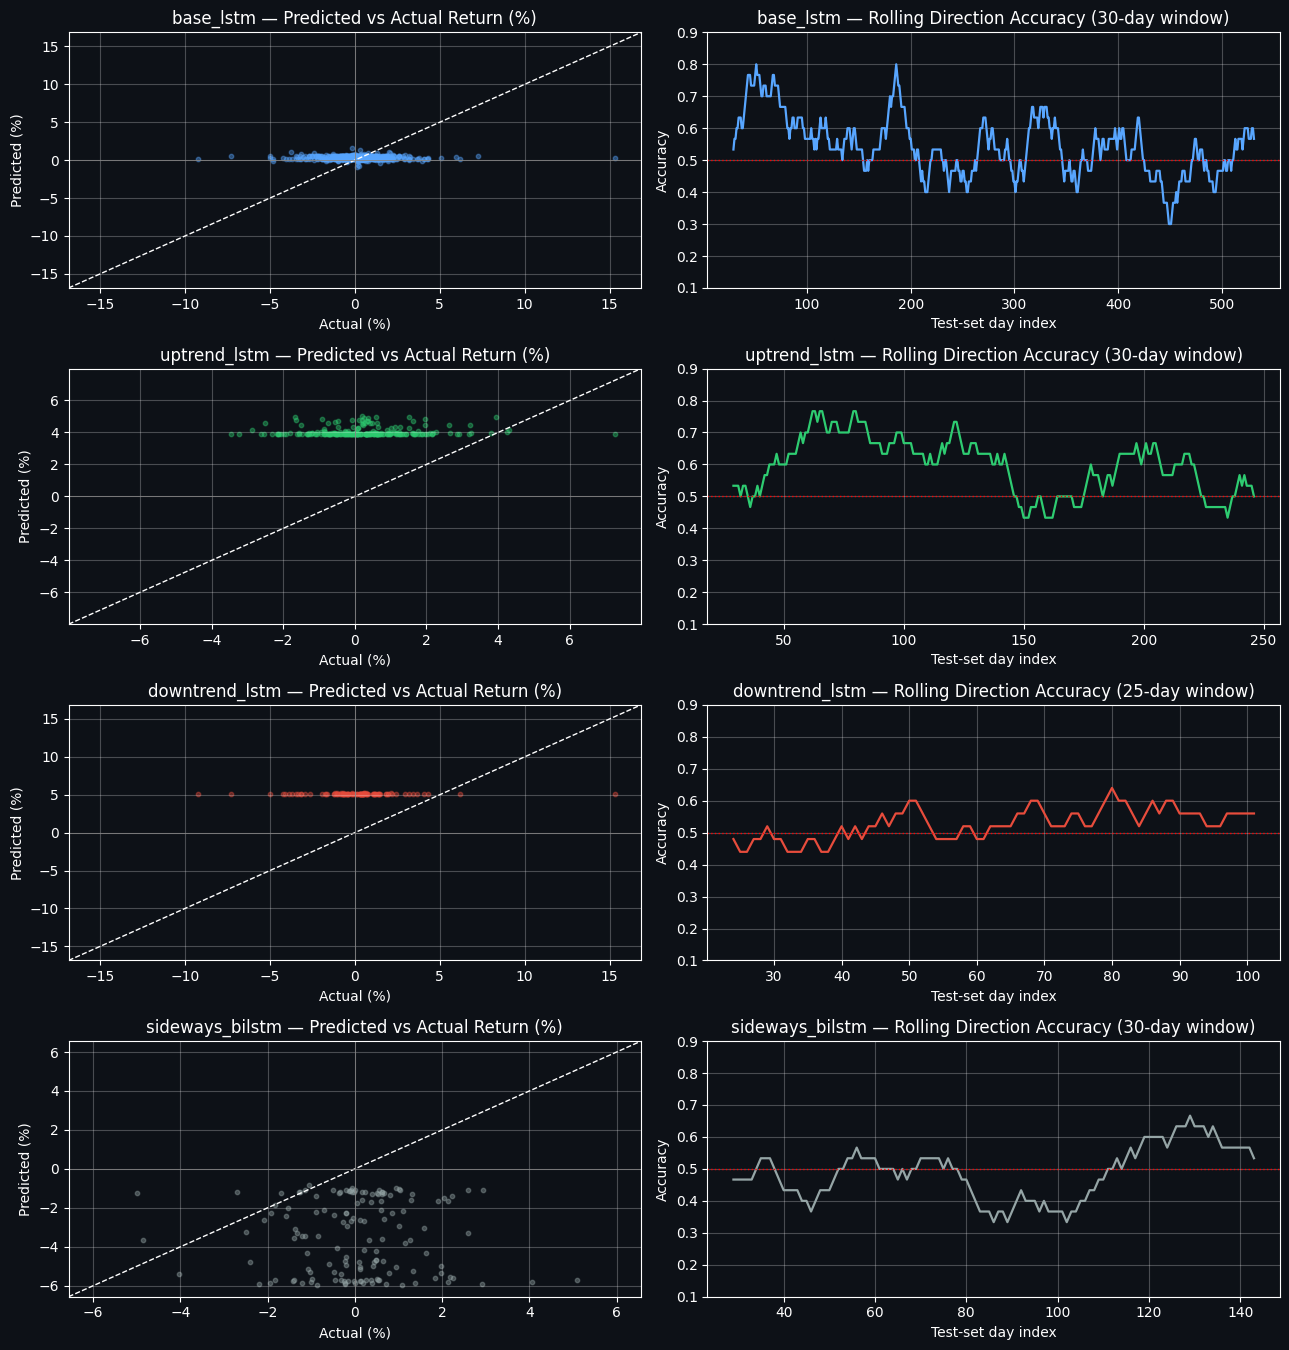

In [ ]:
fig, axes = plt.subplots(n, 2, figsize=(13, 3.4 * n))
if n == 1:
    axes = axes.reshape(1, 2)

for row, name in enumerate(MODEL_NAMES):
    m = all_metrics[name]
    y_test, preds = m["y_test"], m["preds"]
    color = color_for(name)

    ax1 = axes[row, 0]
    ax1.scatter(y_test * 100, preds * 100, s=10, alpha=0.4, color=color)
    lim = max(abs(y_test).max(), abs(preds).max()) * 100 * 1.1
    ax1.plot([-lim, lim], [-lim, lim], color="white", lw=1, linestyle="--")
    ax1.axhline(0, color="grey", lw=0.6); ax1.axvline(0, color="grey", lw=0.6)
    ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim)
    ax1.set_title(f"{name} — Predicted vs Actual Return (%)")
    ax1.set_xlabel("Actual (%)"); ax1.set_ylabel("Predicted (%)")

    ax2 = axes[row, 1]
    correct = (preds > 0) == (y_test > 0)
    window  = max(min(30, len(correct) // 4), 2)
    roll_acc = pd.Series(correct).rolling(window).mean()
    ax2.plot(roll_acc, color=color, lw=1.6)
    ax2.axhline(0.5, color="red", lw=1, linestyle=":")
    ax2.set_ylim(0.1, 0.9)
    ax2.set_title(f"{name} — Rolling Direction Accuracy ({window}-day window)")
    ax2.set_xlabel("Test-set day index"); ax2.set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/fig_prediction_quality.png", dpi=140)
plt.show()


## 6. Actual Up vs Predicted Up — directional bias by model

A well-calibrated model should predict roughly as many "Up" days as actually occurred for each regime. A big gap between the two bars signals a systematic over- or under-prediction of one direction.

**Your task — implement the grouped bar chart (cell below):**

1. For each model name compute:
   - `actual_up_counts`: number of test-set days where `y_test > 0`.
   - `predicted_up_counts`: number of test-set days where `preds > 0`.
2. Create a grouped bar chart with two bars per model (side-by-side, width `0.38`):
   - **Actual Up** bars in `"#2ecc71"` (offset left by `width/2`).
   - **Predicted Up** bars in `"#58a6ff"` (offset right by `width/2`).
3. Add x-tick labels (model names, rotated 20°), a y-label, a legend, a title, and a light horizontal grid.
4. Save to `f"{REPORTS_DIR}/fig_actual_vs_predicted_up.png"` at `dpi=140`.


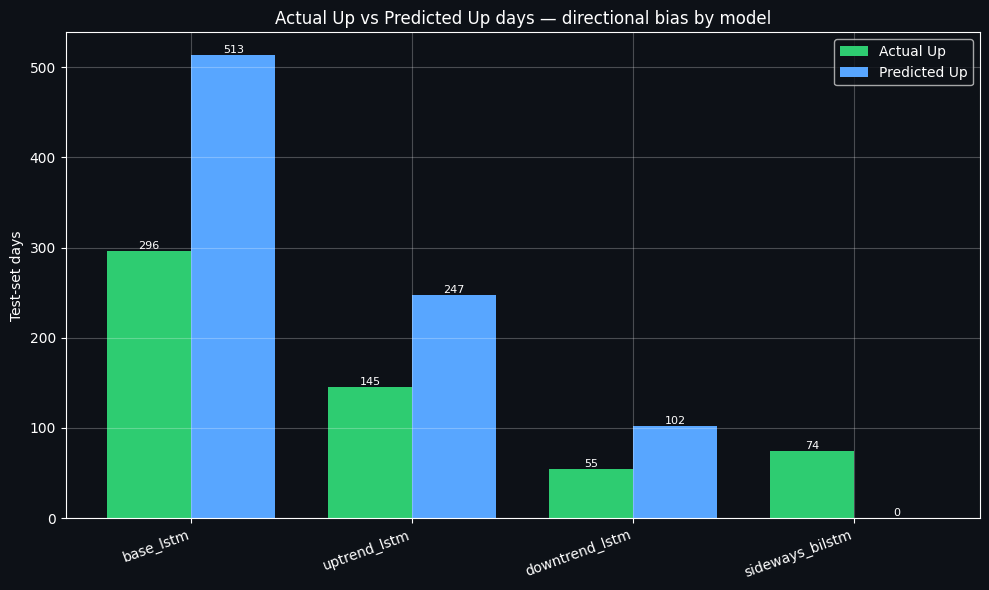

In [ ]:
actual_up_counts    = [int((all_metrics[name]["y_test"] > 0).sum()) for name in MODEL_NAMES]
predicted_up_counts = [int((all_metrics[name]["preds"] > 0).sum())  for name in MODEL_NAMES]

x = np.arange(len(MODEL_NAMES))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
bars_actual = ax.bar(x - width / 2, actual_up_counts, width,
                     label="Actual Up", color="#2ecc71")
bars_pred   = ax.bar(x + width / 2, predicted_up_counts, width,
                     label="Predicted Up", color="#58a6ff")

for bar in list(bars_actual) + list(bars_pred):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha="right")
ax.set_ylabel("Test-set days")
ax.set_title("Actual Up vs Predicted Up days — directional bias by model")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/fig_actual_vs_predicted_up.png", dpi=140)
plt.show()


## 7. Summary table


In [ ]:
summary = pd.DataFrame([
    {"model": n, "n_train": m["n_train"], "n_test": m["n_test"],
     "RMSE": round(m["test_rmse"], 5), "dir_acc": round(m["direction_accuracy"], 3),
     "f1": round(m["f1_score"], 3)}
    for n, m in all_metrics.items()
])
summary


,model,n_train,n_test,RMSE,dir_acc,f1
0,base_lstm,1803,532,0.01808,0.543,0.700
1,uptrend_lstm,832,247,0.04035,0.587,0.740
2,downtrend_lstm,342,102,0.05760,0.539,0.701
3,sideways_bilstm,485,144,0.04256,0.486,0.000


## How to read this notebook's output

- **Loss curves climbing back up** after an early dip on a regime model usually means too little
  data for that regime's capacity — check its sample count in the summary table first.
- **Confusion matrices skewed heavily to one column** mean direction accuracy near 50% isn't
  telling the whole story — the model may be defaulting to one side rather than genuinely
  discriminating. This is most likely on the smallest regimes, where the actual directional
  signal in the data is thinnest.
- **A large gap between the "Actual Up" and "Predicted Up" bars** for a given model is the same
  signal viewed from the test-set-totals angle rather than per-prediction — check that model's
  confusion matrix above to see which direction it's leaning toward.
- **A regime model that doesn't beat the baseline** on its own metrics isn't earning its
  complexity — in a production system, route that regime back to the baseline model instead of
  its dedicated one.
- Direction accuracy hovering close to 50% across the board is a realistic outcome for
  short-horizon stock return prediction — it does not mean the pipeline is broken, it means the
  actual exploitable signal in the data is small. Treat any single run's numbers as one sample
  from a noisy process, not a verdict.
